<a href="https://colab.research.google.com/github/meliskmb/movie-genre-classification/blob/main/movie_genre_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np
import sklearn
import nltk
import spacy

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
df = pd.read_csv('/content/drive/My Drive/CSV Dosyaları/imdb_top_1000.csv')
df.head()

,Poster_Link,Series_Title,Released_Year,Certificate,Runtime,Genre,IMDB_Rating,Overview,Meta_score,Director,Star1,Star2,Star3,Star4,No_of_Votes,Gross
0,https://m.media-amazon.com/images/M/MV5BMDFkYT...,The Shawshank Redemption,1994,A,142 min,Drama,9.3,Two imprisoned men bond over a number of years...,80.0,Frank Darabont,Tim Robbins,Morgan Freeman,Bob Gunton,William Sadler,2343110,"28,341,469"
1,https://m.media-amazon.com/images/M/MV5BM2MyNj...,The Godfather,1972,A,175 min,"Crime, Drama",9.2,An organized crime dynasty's aging patriarch t...,100.0,Francis Ford Coppola,Marlon Brando,Al Pacino,James Caan,Diane Keaton,1620367,"134,966,411"
2,https://m.media-amazon.com/images/M/MV5BMTMxNT...,The Dark Knight,2008,UA,152 min,"Action, Crime, Drama",9.0,When the menace known as the Joker wreaks havo...,84.0,Christopher Nolan,Christian Bale,Heath Ledger,Aaron Eckhart,Michael Caine,2303232,"534,858,444"
3,https://m.media-amazon.com/images/M/MV5BMWMwMG...,The Godfather: Part II,1974,A,202 min,"Crime, Drama",9.0,The early life and career of Vito Corleone in ...,90.0,Francis Ford Coppola,Al Pacino,Robert De Niro,Robert Duvall,Diane Keaton,1129952,"57,300,000"
4,https://m.media-amazon.com/images/M/MV5BMWU4N2...,12 Angry Men,1957,U,96 min,"Crime, Drama",9.0,A jury holdout attempts to prevent a miscarria...,96.0,Sidney Lumet,Henry Fonda,Lee J. Cobb,Martin Balsam,John Fiedler,689845,"4,360,000"


In [ ]:
df = df[["Overview", "Genre"]]
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Overview  1000 non-null   object
 1   Genre     1000 non-null   object
dtypes: object(2)
memory usage: 15.8+ KB


In [ ]:
# NLP pre-processing = küçük harfe çevir, noktalama işaretlerini kaldır, stopword(önemsiz kelime) kaldır, lemmatization(kelime köküne inme)
# NLTK(Natural Language Toolkit)
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize # Bir metni kelimelere veya cümlelere ayırma işlemi. Modelin öğrenmesi için gerekli temel adım.
from nltk.stem import WordNetLemmatizer # "running" → "run", "better" → "good"
import string # noktalama işaretlerini temizlemek için
import re

nltk.download('stopwords')
nltk.download('punkt') # Tokenization için
nltk.download('wordnet') # Lemmatization için

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to /root/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


True

In [ ]:
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()
nltk.download('punkt_tab')

def preprocess_text(text):
    text = text.lower()
    text = re.sub(r'@\S+', '', text)  # Twitter handle'ları kaldır
    text = re.sub(r'http\S+', '', text)  # URL'leri kaldır
    text = re.sub(r'pic.\S+', '', text)  # Resim linklerini kaldır
    text = re.sub(r"[^a-zA-Z+']", ' ', text)  # Sadece harfleri tut
    text = re.sub(r'\s+[a-zA-Z]\s+', ' ', text + ' ')  # Tek harfli kelimeleri kaldır
    text = text.translate(str.maketrans('', '', string.punctuation)) # Noktalama işaretlerini kaldır
    words = word_tokenize(text)
    words = [lemmatizer.lemmatize(word) for word in words if word not in stop_words]
    text = ' '.join(words)
    text = re.sub("\s[\s]+", " ", text).strip()  # Fazladan boşlukları temizle
    return text

df['Genre'] = df['Genre'].apply(lambda x: x.split(',')[0].strip())
df["Cleaned_overview"] = df["Overview"].apply(preprocess_text)

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [ ]:
df[["Cleaned_overview", "Genre"]].head()
print(df['Genre'].value_counts())

Genre
Drama                289
Action               172
Comedy               155
Crime/Mystery        122
Biography             88
Family/Animation      84
Fantasy/Adventure     78
Horror/Thriller       12
Name: count, dtype: int64


In [ ]:
def merge_genres(genre):
    if genre in ["Thriller", "Horror"]:
        return "Horror/Thriller"
    elif genre in ["Fantasy", "Adventure", "Western"]:
        return "Fantasy/Adventure"
    elif genre in ["Family", "Animation"]:
        return "Family/Animation"
    elif genre in ["Film-Noir", "Crime", "Mystery"]:
        return "Crime/Mystery"
    else:
        return genre

df['Genre'] = df['Genre'].apply(merge_genres)

In [ ]:
print(df['Genre'].value_counts())
df.head()

Genre
Drama                289
Action               172
Comedy               155
Crime/Mystery        122
Biography             88
Family/Animation      84
Fantasy/Adventure     78
Horror/Thriller       12
Name: count, dtype: int64


,Overview,Genre,Cleaned_overview
0,Two imprisoned men bond over a number of years...,Drama,two imprisoned men bond number year finding so...
1,An organized crime dynasty's aging patriarch t...,Crime/Mystery,organized crime dynasty aging patriarch transf...
2,When the menace known as the Joker wreaks havo...,Action,menace known joker wreaks havoc chaos people g...
3,The early life and career of Vito Corleone in ...,Crime/Mystery,early life career vito corleone new york city ...
4,A jury holdout attempts to prevent a miscarria...,Crime/Mystery,jury holdout attempt prevent miscarriage justi...


Text(0, 0.5, 'Genre')

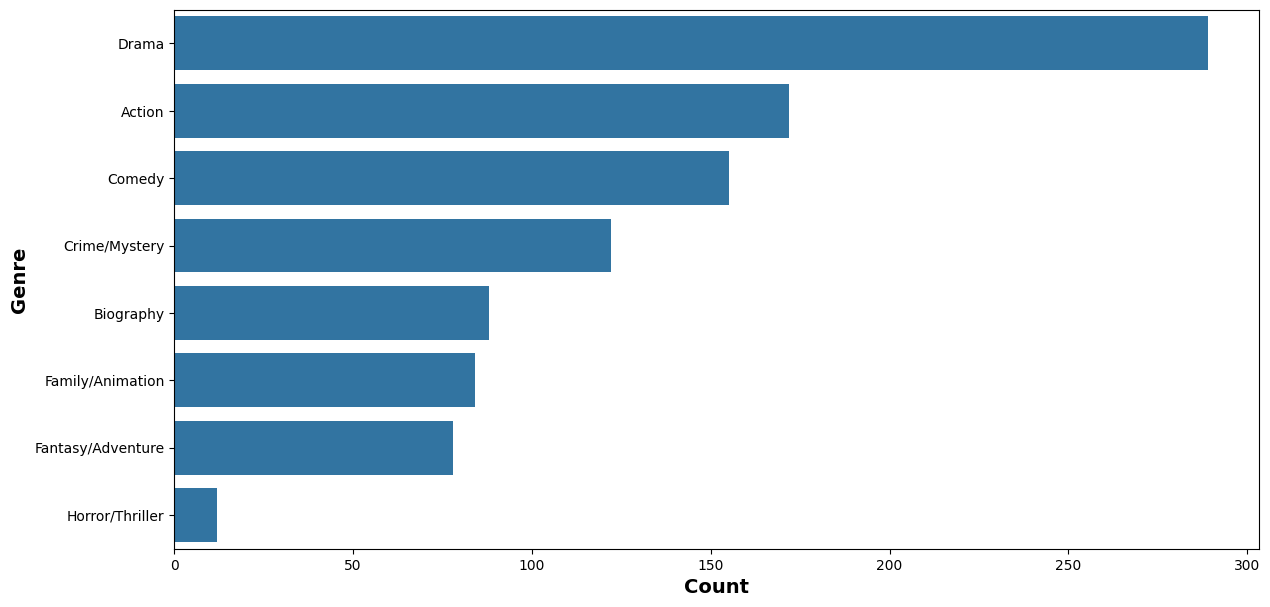

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(14, 7))
sns.countplot(data=df, y='Genre', order=df['Genre'].value_counts().index)
plt.xlabel('Count', fontsize=14, fontweight='bold')
plt.ylabel('Genre', fontsize=14, fontweight='bold')

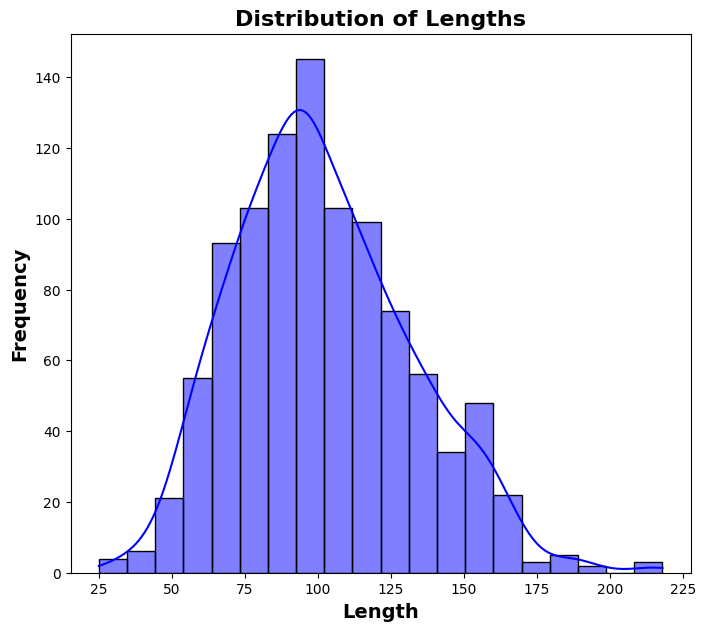

In [ ]:
df['length_Cleaned_overview'] = df['Cleaned_overview'].apply(len)
# Visualize the distribution of text lengths
plt.figure(figsize=(8, 7))
sns.histplot(data=df, x='length_Cleaned_overview', bins=20, kde=True, color='blue')
plt.xlabel('Length', fontsize=14, fontweight='bold')
plt.ylabel('Frequency', fontsize=14, fontweight='bold')
plt.title('Distribution of Lengths', fontsize=16, fontweight='bold')
plt.show()

In [ ]:
from sklearn.model_selection import train_test_split
X = df["Cleaned_overview"] # Bağımsız değişken
y = df["Genre"] # Bağımlı değişken

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Toplam veri: {len(df)}")
print(f"Eğitim verisi: {len(X_train)}")
print(f"Test verisi: {len(X_test)}")

Toplam veri: 1000
Eğitim verisi: 800
Test verisi: 200


In [ ]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [ ]:
vectorizer = TfidfVectorizer(max_features=15000, ngram_range=(1,2))
X_train_tfidf = vectorizer.fit_transform(X_train)
X_test_tfidf = vectorizer.transform(X_test)
print(f"TF-IDF Dönüşümünden Sonra Eğitim Verisi Boyutu: {X_train_tfidf.shape}")

TF-IDF Dönüşümünden Sonra Eğitim Verisi Boyutu: (800, 14709)


In [ ]:
from sklearn.metrics import accuracy_score, classification_report

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(class_weight='balanced', solver='liblinear', C=1.5, max_iter=1000)
model.fit(X_train_tfidf, y_train)

y_pred = model.predict(X_test_tfidf)

accuracy = accuracy_score(y_test, y_pred)
print(f"Yeni Logistic Regression Doğruluk Oranı: {accuracy:.2f}")

Yeni Logistic Regression Doğruluk Oranı: 0.43


In [ ]:
accuracy = accuracy_score(y_test, y_pred)
print(f"Model Doğruluk Oranı: {accuracy:.2f}")
print(classification_report(y_test, y_pred))

Model Doğruluk Oranı: 0.43
                   precision    recall  f1-score   support

           Action       0.53      0.59      0.56        29
        Biography       0.62      0.24      0.34        21
           Comedy       0.40      0.27      0.32        30
    Crime/Mystery       0.31      0.19      0.24        21
            Drama       0.39      0.73      0.51        63
 Family/Animation       0.83      0.25      0.38        20
Fantasy/Adventure       0.00      0.00      0.00        15
  Horror/Thriller       1.00      1.00      1.00         1

         accuracy                           0.43       200
        macro avg       0.51      0.41      0.42       200
     weighted avg       0.45      0.43      0.39       200

